<a href="https://colab.research.google.com/github/ProfAI/machine-learning-modelli-e-algoritmi/blob/main/6%20-%20Nearest%20Neighbors/nearest_neighbors_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Face Recognition con K-Nearest Neighbors

In questa esercitazione applicheremo l'algoritmo **K-Nearest Neighbors (K-NN)** per costruire un sistema di **Face Recognition** (riconoscimento facciale) in grado di identificare 40 persone differenti.

### Olivetti Faces Dataset

Il dataset utilizzato è l'**Olivetti Faces Dataset** composto da:
- **400 immagini** in scala di grigi totali (10 immagini diverse per ciascuna delle 40 persone).
- Ciascuna immagine ha dimensioni **$64 \times 64$ pixel**.
- Le foto presentano variazioni di luce, espressioni facciali (occhi aperti/chiusi, sorridente/serio) e accessori (es. occhiali).

### Obiettivi dell'Esercitazione
1. Caricare e visualizzare il dataset di immagini.
2. Riorganizzare e normalizzare le immagini per l'addestramento.
3. Addestrare un classificatore K-NN e ottimizzare l'accuratezza del modello sul set di test per **superare la soglia dell' $80\%$**.
4. Utilizzare il modello addestrato per determinare quale delle 40 persone del dataset assomiglia di più a una foto custom inserita (`me.jpg`).

In [1]:
!wget https://github.com/ProfAI/machine-learning-modelli-e-algoritmi/raw/main/datasets/olivetti_faces.zip
!unzip -o olivetti_faces.zip

--2026-06-21 20:01:14--  https://github.com/ProfAI/machine-learning-modelli-e-algoritmi/raw/main/datasets/olivetti_faces.zip
Resolving github.com (github.com)... 140.82.121.3
Connecting to github.com (github.com)|140.82.121.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/ProfAI/machine-learning-modelli-e-algoritmi/main/datasets/olivetti_faces.zip [following]
--2026-06-21 20:01:14--  https://raw.githubusercontent.com/ProfAI/machine-learning-modelli-e-algoritmi/main/datasets/olivetti_faces.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 912321 (891K) [application/zip]
Saving to: ‘olivetti_faces.zip.4’

olivetti_faces.zip. 100%[===================>] 890.94K  --.-KB/s    in 0.08s   

2026-06-

In [2]:
# !rm -r olivetti_faces

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from os import listdir
import cv2

In [4]:
RANDOM_SEED = 0
img_size = (64, 64)

### Caricamento delle Immagini

Per caricare le immagini dal file system, utilizziamo OpenCV (`cv2`). Leggiamo ciascuna immagine del dataset in **scala di grigi**, le accumuliamo nella lista `X` e memorizziamo l'identificativo numerico della persona (il nome della cartella da `0` a `39`) nella lista delle etichette `y`.

In [5]:
FOLDER = "olivetti_faces"

X = []
y = []

for dir in listdir(FOLDER):
  path = FOLDER+"/"+dir+"/"
  for f in listdir(path):
    if ".jpg" in f:
      x = cv2.imread(path+f, cv2.IMREAD_GRAYSCALE)
      X.append(x)
      y.append(dir)

X = np.array(X)
y = np.array(y)

X.shape

(400, 64, 64)

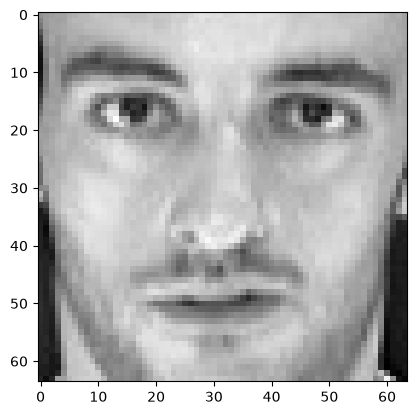

In [6]:
plt.imshow(X[0], cmap="gray")

### Appiattimento delle Immagini (Flattening)

Scikit-learn si aspetta dati bidimensionali di forma `(n_samples, n_features)`. 
Le nostre immagini sono matrici 2D di dimensione $64 \times 64$ pixel. Dobbiamo appiattire ciascuna immagine in un vettore monodimensionale di pixel:

$$64 \times 64 = 4096 \text{ feature}$$

Dopo questa trasformazione, la matrice `X` avrà dimensioni `(400, 4096)`.

In [7]:
X = X.reshape(X.shape[0], X.shape[1]*X.shape[2])
X.shape

(400, 4096)

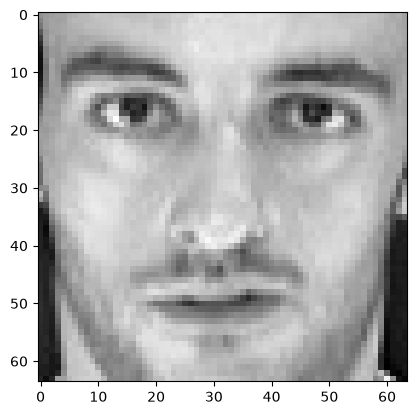

In [8]:
plt.imshow(X[0].reshape(img_size[0], img_size[1]), cmap="gray")

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=RANDOM_SEED)

### Normalizzazione delle Feature

I pixel dell'immagine hanno intensità originaria compresa tra $0$ e $255$.
Dividendo tutti i valori per $255$, riscaliamo i pixel nell'intervallo $[0, 1]$. 
Come abbiamo visto nella teoria del K-NN e Radius NN, riscalare le feature è fondamentale per garantire che la distanza euclidea sia computata correttamente senza distorsioni di scala.

In [10]:
X_train = X_train/255
X_test = X_test/255

### Controllo delle Classi nel Set di Test

Verifichiamo che tutte le classi (persone) presenti nel test set siano rappresentate anche nel set di addestramento. 
Se una persona fosse presente solo nel test set, l'algoritmo Nearest Neighbors non potrebbe mai indovinarla, poiché non disporrebbe di alcun campione simile memorizzato su cui basarsi per calcolare la distanza.

In [11]:
(1-np.isin(y_test, y_train)).sum()

np.int64(0)

In [ ]:
knn = KNeighborsClassifier(metric='manhattan', n_neighbors=2)
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'manhattan'
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[<U2](40,)","['0','1','10',...,'7','8','9']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'ma...an'


In [34]:
knn.score(X_test, y_test)

0.975

### Analisi e Ottimizzazione delle Performance

Il classificatore K-NN di default (`n_neighbors=5`) raggiunge un'accuratezza del **$78.75\%$**.

> [!TIP]
> **Suggerimento per gli studenti**:
> L'esercizio richiede un'accuratezza di **almeno l'80%**.
> Per superare questa soglia e ottimizzare il modello, prova a sperimentare:
> - Cambiando il numero di vicini $K$ (ad esempio, prova valori più bassi come $K=1$ o $K=3$).
> - Modificando il parametro `metric` nel costruttore di `KNeighborsClassifier` (ad esempio, utilizzando la distanza di Manhattan `metric='manhattan'` o la similarità coseno `metric='cosine'`), poiché la distanza euclidea classica può risentire della "maledizione della dimensionalità" su uno spazio a 4096 feature.

### Face Recognition in Azione (Foto Custom)

Ora mettiamo alla prova il sistema facendogli riconoscere la tua foto! 
Puoi caricare un'immagine nominata `me.jpg`. Affinché il modello possa valutarla correttamente, essa deve seguire lo stesso identico flusso di pre-elaborazione applicato alle immagini del dataset:
1. Essere caricata in **scala di grigi**.
2. Essere ridimensionata alle dimensioni del dataset originale: **$64 \times 64$ pixel**.
3. Essere appiattita a un **vettore monodimensionale di 4096 elementi**.
4. Essere normalizzata dividendo per **255**.

Il modello utilizzerà `.predict()` per identificare la persona più vicina e `.predict_proba()` per mostrare le probabilità stimate per ciascuna delle 40 identità.

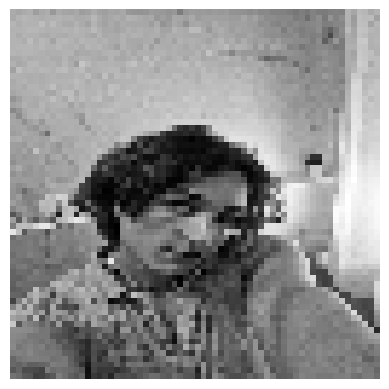

In [35]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = "me.jpg"

if os.path.exists(image_path):
    x = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if x is not None:
        x = cv2.resize(x, img_size)
        plt.imshow(x, cmap="gray")
        plt.axis("off")
        plt.show()
    else:
        print("⚠️ Errore: Impossibile leggere 'me.jpg'. Utilizzo un'immagine vuota di default.")
        x = np.zeros(img_size, dtype=np.uint8)
else:
    print(f"⚠️ Nota: Il file '{image_path}' non è stato trovato.")
    print("Utilizzo un'immagine vuota (placeholder) per non interrompere il flusso del notebook.")
    print("Carica la tua foto 'me.jpg' nella cartella del notebook per testare il modello con il tuo volto.")
    x = np.zeros(img_size, dtype=np.uint8)

In [36]:
x = x.reshape(img_size[0]*img_size[1])
x = x/255

In [37]:
x.shape

(4096,)

In [38]:
y_pred = knn.predict([x])
y_pred

array(['14'], dtype='<U2')

In [39]:
y_proba = knn.predict_proba([x])[0]

for i in range(y_proba.shape[0]):
  print(f"Person {knn.classes_[i]} = {y_proba[i]} probability")

Person 0 = 0.0 probability
Person 1 = 0.0 probability
Person 10 = 0.0 probability
Person 11 = 0.0 probability
Person 12 = 0.0 probability
Person 13 = 0.0 probability
Person 14 = 1.0 probability
Person 15 = 0.0 probability
Person 16 = 0.0 probability
Person 17 = 0.0 probability
Person 18 = 0.0 probability
Person 19 = 0.0 probability
Person 2 = 0.0 probability
Person 20 = 0.0 probability
Person 21 = 0.0 probability
Person 22 = 0.0 probability
Person 23 = 0.0 probability
Person 24 = 0.0 probability
Person 25 = 0.0 probability
Person 26 = 0.0 probability
Person 27 = 0.0 probability
Person 28 = 0.0 probability
Person 29 = 0.0 probability
Person 3 = 0.0 probability
Person 30 = 0.0 probability
Person 31 = 0.0 probability
Person 32 = 0.0 probability
Person 33 = 0.0 probability
Person 34 = 0.0 probability
Person 35 = 0.0 probability
Person 36 = 0.0 probability
Person 37 = 0.0 probability
Person 38 = 0.0 probability
Person 39 = 0.0 probability
Person 4 = 0.0 probability
Person 5 = 0.0 probabilit